In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Activamos el grid por defecto por comodidad
plt.rcParams['axes.grid'] = True          # Activa el grid por defecto
plt.rcParams['grid.linestyle'] = '--'     # Estilo de línea discontinua
plt.rcParams['grid.alpha'] = 0.5          # Semitransparencia (0 es invisible, 1 es opaco)
plt.rcParams['grid.color'] = 'gray'

pd.options.display.float_format = '{:.2f}'.format # Para mostrar hasta 2 decimales

archivo = "Trabajo_Almacenamiento_Eléctrico_python.xlsx"
# Leemos las hojas que tenemos
print(pd.ExcelFile(archivo).sheet_names)

['Power instaled', 'Potencia instalada', 'Generation 2023', 'Generation 2030 Renovable']


En este Excel tenemos varias hojas.
La hoja "Power Instaled" es la dada por el enunciado de ejemplo la cual modificamos para tener los datos en tablas que ponemos en la hoja "Potencia Instalada", dónde se calcula la proporcionalidad de potencia instalada que tenemos a lo largo del año para extrapolar la producción al año 2030.

In [140]:
df_Pins = pd.read_excel(archivo, sheet_name="Potencia instalada", header=0)

# TABLA 1: Evolución mensual 2023
# Datos de la fila 1 a la 11, columnas de la 0 a la 12
df_potencia_2023 = df_Pins.iloc[1:12, 0:13].copy()
df_potencia_2023.columns = df_Pins.iloc[0, 0:13].values
df_potencia_2023.reset_index(drop=True, inplace=True)

print("--- DATOS 2023 ---")
display(df_potencia_2023)

# TABLA 2: PNIEC Peninsular 2030
# Datos de la fila 1 a la 11, columnas 14 y 15
df_pniec_2030 = df_Pins.iloc[1:12, 14:16].copy()
df_pniec_2030.columns = ["Energía", "Potencia_MW"]
df_pniec_2030.reset_index(drop=True, inplace=True)

print("\n--- DATOS PNIEC 2030 ---")
display(df_pniec_2030)

# TABLA 3: Proporcionalidades
# Las cabeceras están en la fila 16, y los datos van de la 17 a la 27. Columnas de la 0 a la 12
df_proporcionalidad = df_Pins.iloc[17:28, 0:13].copy()
df_proporcionalidad.columns = df_Pins.iloc[16, 0:13].values
df_proporcionalidad.reset_index(drop=True, inplace=True)

print("\n--- PROPORCIONALIDADES ---")
display(df_proporcionalidad)

--- DATOS 2023 ---


,Energía,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,Nuclear,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29
1,Fuel,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95
2,Carbón,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16
3,Ciclos,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85
4,Cogeneración y otros,5976.98,5976.98,5976.98,5976.98,5976.68,5976.68,5976.68,5976.68,5976.68,5968.91,5968.91,5968.91
5,Hidráulica,20424.78,20424.78,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21
6,Eólica,29596.04,29670.49,29720.39,29731.39,29768.39,29833.69,29854.31,29900.71,29923.91,30000.71,30095.11,30100.11
7,Solar FV,19761.00,20184.67,20719.38,21076.89,21358.35,22314.49,22530.63,23007.78,23358.66,23881.77,24358.21,24561.74
8,Termosolar,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01
9,Resto RES,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98



--- DATOS PNIEC 2030 ---


,Energía,Potencia_MW
0,Nuclear,3041
1,Fuel,0
2,Carbón,0
3,Ciclos,24498
4,Cogeneración y otros,4071
5,Hidráulica,14561
6,Eólica,60312
7,Solar FV,72751
8,Termosolar,4800
9,Resto RES,1964



--- PROPORCIONALIDADES ---


,Energía,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,Nuclear,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43
1,Fuel,0,0,0,0,0,0,0,0,0,0,0,0
2,Carbón,0,0,0,0,0,0,0,0,0,0,0,0
3,Ciclos,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
4,Cogeneración y otros,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68
5,Hidráulica,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71
6,Eólica,2.04,2.03,2.03,2.03,2.03,2.02,2.02,2.02,2.02,2.01,2.00,2.00
7,Solar FV,3.68,3.60,3.51,3.45,3.41,3.26,3.23,3.16,3.11,3.05,2.99,2.96
8,Termosolar,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08
9,Resto RES,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61


In [141]:
df_2023 = pd.read_excel(archivo, sheet_name="Generation 2023", header=3)

df_2023 = df_2023.iloc[:105120].copy()
df_2023.head(5) # Mostramos 5 filas para comprobar que esté funcionando

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,6465.00,0,251.00,2296.00,929.00,552.00,7054.00,20.00,0.00,253.00,17820.00,7626.00,10194.00,0.43
1,Enero,2023-01-01,00:05:00,6468.00,0,276.00,2278.00,936.00,229.00,6702.00,20.00,0.00,236.00,17145.00,6951.00,10194.00,0.41
2,Enero,2023-01-01,00:10:00,6470.00,0,289.00,2341.00,935.00,204.00,6295.00,20.00,0.00,236.00,16790.00,6519.00,10271.00,0.39
3,Enero,2023-01-01,00:15:00,6467.00,0,292.00,2286.00,945.00,168.00,6230.00,20.00,0.00,236.00,16644.00,6418.00,10226.00,0.39
4,Enero,2023-01-01,00:20:00,6465.00,0,301.00,2227.00,936.00,145.00,6129.00,20.00,0.00,236.00,16459.00,6294.00,10165.00,0.38


Con la demanda del 2023 y la tabla previa de proporcionalidad calculamos la Generación del 2030. (Este cálculo se realizó en Excel en la hoja "Generation 2030 Renovable")

In [142]:
df_2030r = pd.read_excel(archivo, sheet_name="Generation 2030 Renovable", header=3)

df_2030r = df_2030r.iloc[:105120].copy()
df_2030r.head(5) # Mostramos 5 filas para comprobar que esté funcionando

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,2762.30,0.00,0.00,2290.03,632.75,393.53,14374.92,73.63,0.00,407.63,20934.79,15249.71,5685.08,0.73
1,Enero,2023-01-01,00:05:00,2763.58,0.00,0.00,2272.08,637.52,163.26,13657.60,73.63,0.00,380.24,19947.91,14274.73,5673.18,0.72
2,Enero,2023-01-01,00:10:00,2764.43,0.00,0.00,2334.91,636.84,145.43,12828.20,73.63,0.00,380.24,19163.70,13427.51,5736.19,0.70
3,Enero,2023-01-01,00:15:00,2763.15,0.00,0.00,2280.06,643.65,119.77,12695.74,73.63,0.00,380.24,18956.24,13269.38,5686.86,0.70
4,Enero,2023-01-01,00:20:00,2762.30,0.00,0.00,2221.21,637.52,103.37,12489.92,73.63,0.00,380.24,18668.19,13047.16,5621.03,0.70


En el enunciado mencionan que consideremos que la demanda aumenta un 16%, de manera que calculamos el consumo en 2030 en base a la demanda del 2023.

In [143]:
Aumento_consumo= 0.16
df_2023["Consumo_2030"] = df_2023["Total"] * (1 + Aumento_consumo)
df_2023[["Total", "Consumo_2030"]].head(5)

,Total,Consumo_2030
0,17820.00,20671.20
1,17145.00,19888.20
2,16790.00,19476.40
3,16644.00,19307.04
4,16459.00,19092.44


# Renovable

Lo primero a analizar es la posibilidad de utilizar sólo energía renovable, demanera que se considera la posibilidad de utilizar almacenamiento. Para ellos calculamos el balance de energía según necesidad o excedente de manera que se pueda utilizar estos excedenetes en momento s de alta demanda.

In [144]:
# Escenario Renovable
esc_r = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hora": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"]})

In [145]:
esc_r["Balance"] = esc_r["Renovable"] - esc_r["Consumo"]

# positivo = excedente de energía
# negativo = falta energía

esc_r.head(5)

,Fecha,Hora,Consumo,Renovable,Balance
0,2023-01-01,00:00:00,20671.20,15249.71,-5421.49
1,2023-01-01,00:05:00,19888.20,14274.73,-5613.47
2,2023-01-01,00:10:00,19476.40,13427.51,-6048.89
3,2023-01-01,00:15:00,19307.04,13269.38,-6037.66
4,2023-01-01,00:20:00,19092.44,13047.16,-6045.28


In [146]:
consumo_total_mwh = esc_r["Consumo"].sum() / 12
renovable_total_mwh = esc_r["Renovable"].sum() / 12

# Balance < 0 significa que el Consumo es mayor que la Renovable (FALTA energía)
deficit_total_mwh = esc_r.loc[esc_r["Balance"] < 0, "Balance"].sum() / 12

# Balance < 0 significa que la Renovable es mayor que el Consumo (SOBRA energía)
excedente_total_mwh = esc_r.loc[esc_r["Balance"] > 0, "Balance"].sum() / 12

tabla_resumen = pd.DataFrame({
    "Concepto": [
        "Consumo Anual Total", 
        "Generación Renovable Total", 
        "Déficit Total", 
        "Excedente Total"],
    "Energía (MWh)": [
        consumo_total_mwh, 
        renovable_total_mwh, 
        deficit_total_mwh, 
        excedente_total_mwh]})

tabla_resumen["Energía (MWh)"] = tabla_resumen["Energía (MWh)"].round(2)
display(tabla_resumen)

,Concepto,Energía (MWh)
0,Consumo Anual Total,281995331.45
1,Generación Renovable Total,272843590.96
2,Déficit Total,-56520945.83
3,Excedente Total,47369205.34


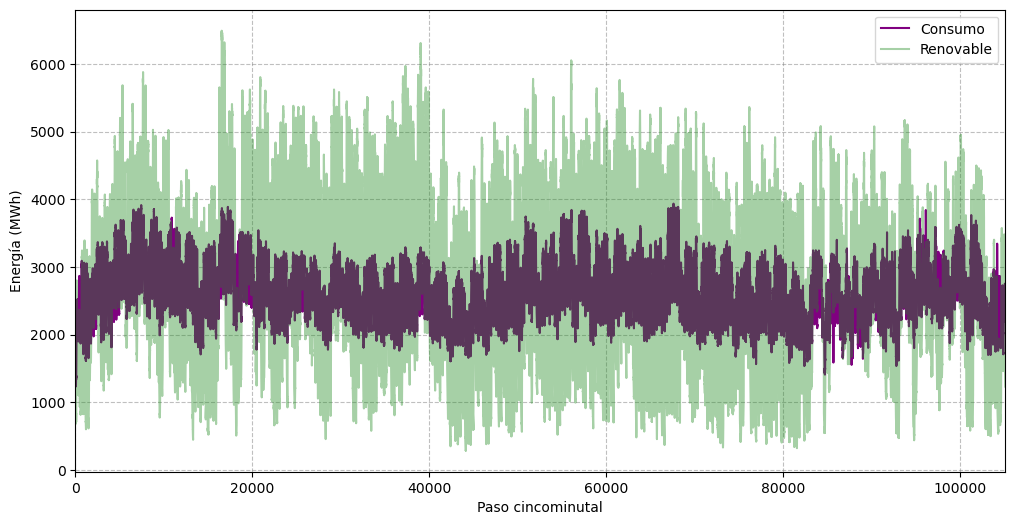

In [147]:
plt.figure(figsize=(12,6))

plt.plot(esc_r["Consumo"]/12, label="Consumo", alpha=1, color="purple")
plt.plot(esc_r["Renovable"]/12, label="Renovable", alpha=0.4, color="forestgreen")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")

plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("Gen_R.png", dpi=300, bbox_inches='tight')

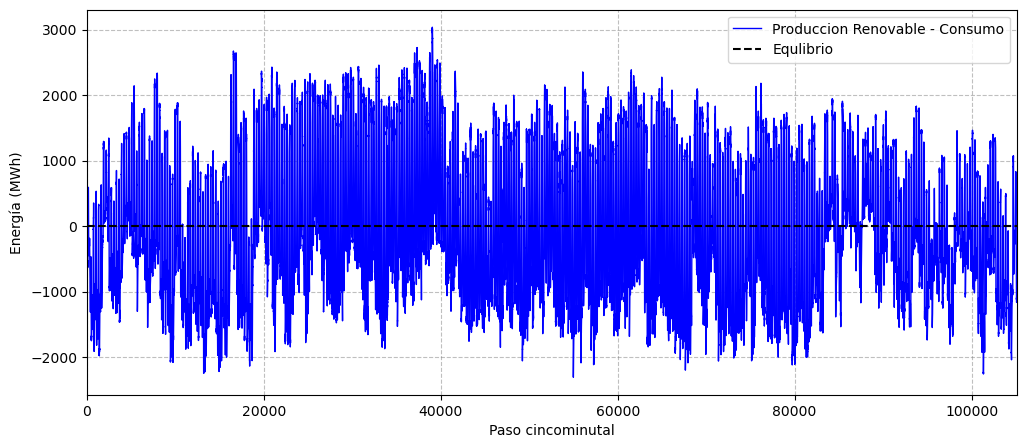

In [148]:
plt.figure(figsize=(12, 5))

plt.plot(esc_r["Balance"]/12, label="Produccion Renovable - Consumo", color="blue", linewidth=1)
plt.axhline(0, color="black", linestyle="--", linewidth=1.5, label="Equlibrio")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("balance_R.png", dpi=300, bbox_inches='tight')

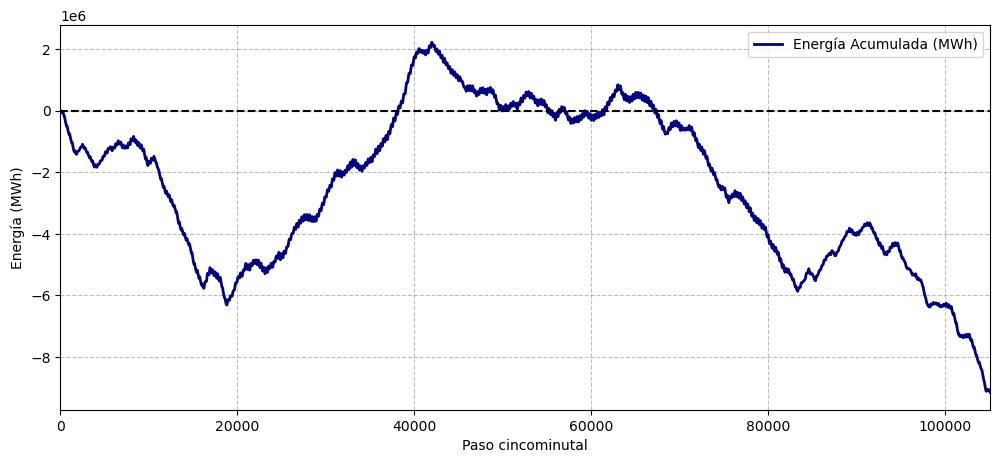

In [149]:
plt.figure(figsize=(12, 5))
balance_acumulado = esc_r["Balance"].cumsum() / 12

plt.plot(balance_acumulado, label="Energía Acumulada (MWh)", color="navy", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1.5,)

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("balance_acumulado_R_MWh.png", dpi=300, bbox_inches='tight')

A continuación, se busca el almacenamiento mínimo para cubrir la demanda energética. Se analizará de manera que el almacenamiento mínimo sea el 10% del máximo, además de buscar una constante base de la que partir a principio de año.

In [150]:
def optimizar_almacenamiento_minimo(df, col_gen, col_cons = "Consumo", frac_min = 0.1): 
                                # Dataframe dónde se haya nuestros datos, generación, consumo y % de reserva
    out = df.copy()

    delta = out[col_gen] - out[col_cons] # Diferencias entre columnas de generación y consumo

    C = delta.cumsum() # Constante

    Cmin = C.min() # Almacenamiento mínimo
    Cmax = C.max() # Almacenamiento máximo

    R = Cmax - Cmin 

    S_max = R / (1 - frac_min)

    S_min = frac_min * S_max

    S0 = S_min - Cmin

    almacenamiento = S0 + C

    out["Delta"] = delta
    out["Acumulado"] = C
    out["Almacenamiento_optimo"] = almacenamiento

    return out, S_max, S_min, S0

In [151]:
esc_r_opt, Smax, Smin, S0 = optimizar_almacenamiento_minimo( esc_r, col_gen = "Renovable", col_cons = "Consumo", frac_min = 0.1 )

print(f"Capacidad total almacenamiento Smax: {round(Smax, 2)} (MW) -> {round(Smax / 12, 2)} MWh")
print(f"Capacidad mínima Smin: {round(Smin, 2)} (MW) -> {round(Smin / 12, 2)} MWh")
print(f"Capacidad útil: {round(Smax - Smin, 2)} (MW) -> {round((Smax - Smin) / 12, 2)} MWh")

# Mostramos las 5 primeras filas
display(esc_r_opt.head(5))

Capacidad total almacenamiento Smax: 151621221.91 (MW) -> 12635101.83 MWh
Capacidad mínima Smin: 15162122.19 (MW) -> 1263510.18 MWh
Capacidad útil: 136459099.72 (MW) -> 11371591.64 MWh


,Fecha,Hora,Consumo,Renovable,Balance,Delta,Acumulado,Almacenamiento_optimo
0,2023-01-01,00:00:00,20671.20,15249.71,-5421.49,-5421.49,-5421.49,124977586.62
1,2023-01-01,00:05:00,19888.20,14274.73,-5613.47,-5613.47,-11034.96,124971973.16
2,2023-01-01,00:10:00,19476.40,13427.51,-6048.89,-6048.89,-17083.85,124965924.26
3,2023-01-01,00:15:00,19307.04,13269.38,-6037.66,-6037.66,-23121.51,124959886.61
4,2023-01-01,00:20:00,19092.44,13047.16,-6045.28,-6045.28,-29166.78,124953841.33


In [152]:
delta = esc_r_opt["Delta"]

P_carga = delta.clip(lower=0).max() # Eliminamos < 0
P_descarga = (-delta.clip(upper=0)).max() # Eliminamos > 0

print("Cargas máximas de carga y descarga:")
print(f"Potencia de carga: {round(P_carga, 2)} (MW) -> {round((P_carga) / 12, 2)} MWh")
print(f"Potencia de descarga: {round(P_descarga, 2)} (MW) -> {round((P_descarga) / 12, 2)} MWh")

Cargas máximas de carga y descarga:
Potencia de carga: 36446.87 (MW) -> 3037.24 MWh
Potencia de descarga: 27673.06 (MW) -> 2306.09 MWh


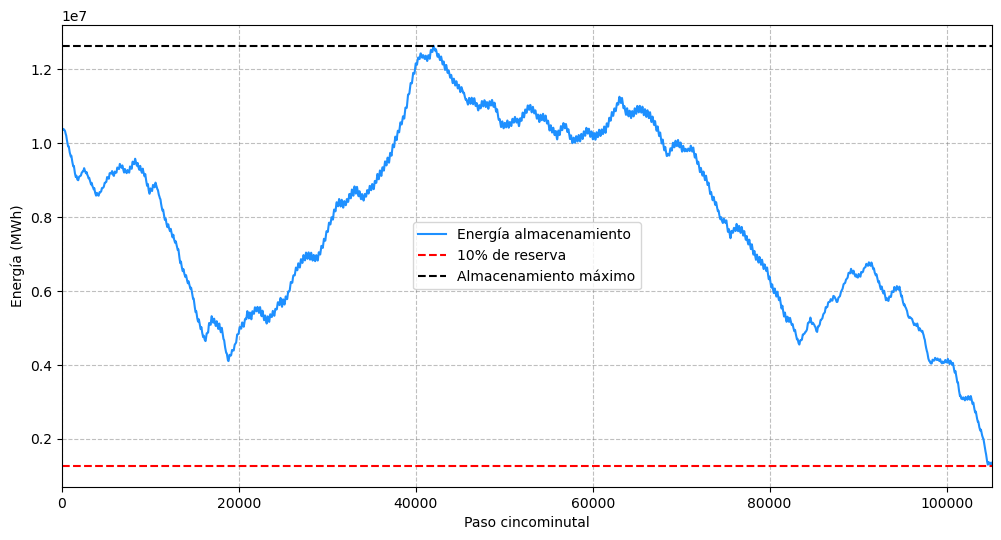

In [153]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_opt["Almacenamiento_optimo"]/12, label="Energía almacenamiento", color="dodgerblue")

plt.axhline(Smin/12, linestyle="--", label="10% de reserva", color="red")
plt.axhline(Smax/12, linestyle="--", label="Almacenamiento máximo", color="black")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")

plt.savefig("Almacenamiento_R.png", dpi=300, bbox_inches='tight')

# Renovable + CCG

En este escenario, en vez de aprovechar toda la energía renovable, la demanda faltante será cubierta por el ciclo combinado de gas (CCG)

In [154]:
# Escenario Renovable + CCG
esc_r_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hora": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"]})

# CCG cubre sólo lo que no cubre la renovable
esc_r_ccg["CCG_necesario"] = np.maximum(esc_r_ccg["Consumo"] - esc_r_ccg["Renovable"], 0)

# Exceso renovable perdido si no hay almacenamiento
esc_r_ccg["Exceso_R_sin_almacenamiento"] = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0) # Los meses de verano

# Generación total del sistema en este caso
esc_r_ccg["Generacion_total"] = esc_r_ccg["Renovable"] + esc_r_ccg["CCG_necesario"]

esc_r_ccg.head(130)

,Fecha,Hora,Consumo,Renovable,CCG_necesario,Exceso_R_sin_almacenamiento,Generacion_total
0,2023-01-01,00:00:00,20671.20,15249.71,5421.49,0.00,20671.20
1,2023-01-01,00:05:00,19888.20,14274.73,5613.47,0.00,19888.20
2,2023-01-01,00:10:00,19476.40,13427.51,6048.89,0.00,19476.40
3,2023-01-01,00:15:00,19307.04,13269.38,6037.66,0.00,19307.04
4,2023-01-01,00:20:00,19092.44,13047.16,6045.28,0.00,19092.44
...,...,...,...,...,...,...,...
125,2023-01-01,10:25:00,20334.80,19528.56,806.24,0.00,20334.80
126,2023-01-01,10:30:00,20668.88,20598.26,70.62,0.00,20668.88
127,2023-01-01,10:35:00,20947.28,22199.24,0.00,1251.96,22199.24
128,2023-01-01,10:40:00,21038.92,22657.43,0.00,1618.51,22657.43


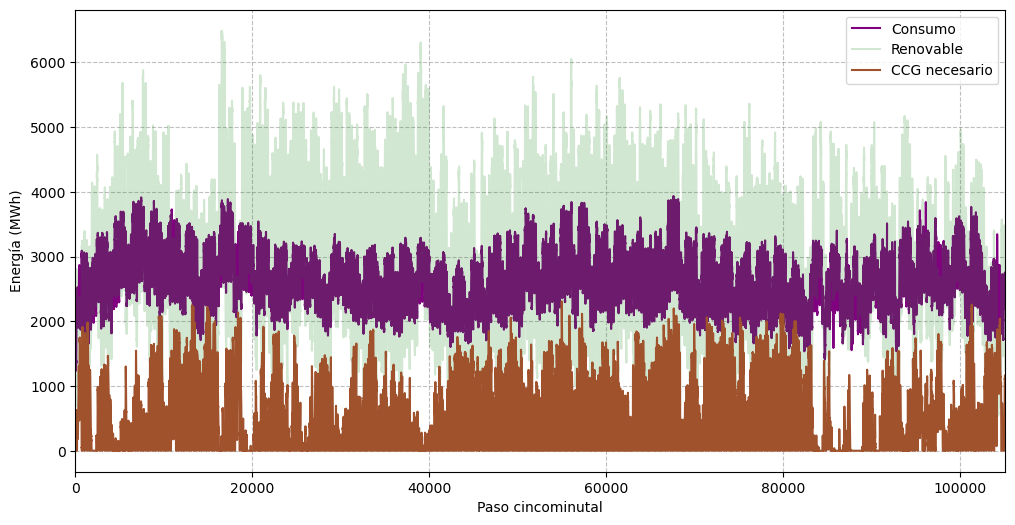

In [155]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Consumo"]/12, label="Consumo",color="purple")
plt.plot(esc_r_ccg["Renovable"]/12, label="Renovable", alpha=0.2, color="forestgreen")
plt.plot(esc_r_ccg["CCG_necesario"]/12, label="CCG necesario", color="sienna")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)

plt.legend(loc = "best")
plt.savefig("Gen_R_CCG.png", dpi=300, bbox_inches='tight')

In [156]:
# 1. Calculamos las sumas totales en MWh
resumen_mwh = (esc_r_ccg[["Consumo", "Renovable", "CCG_necesario", "Exceso_R_sin_almacenamiento", "Generacion_total"]].sum() / 12).to_frame()

resumen_mwh.columns = ["Energía Total (MWh)"]

print("--- RESUMEN DE ENERGÍA ANUAL (MWh) ---")
display(resumen_mwh)

--- RESUMEN DE ENERGÍA ANUAL (MWh) ---


,Energía Total (MWh)
Consumo,281995331.45
Renovable,272843590.96
CCG_necesario,56520945.83
Exceso_R_sin_almacenamiento,47369205.34
Generacion_total,329364536.79


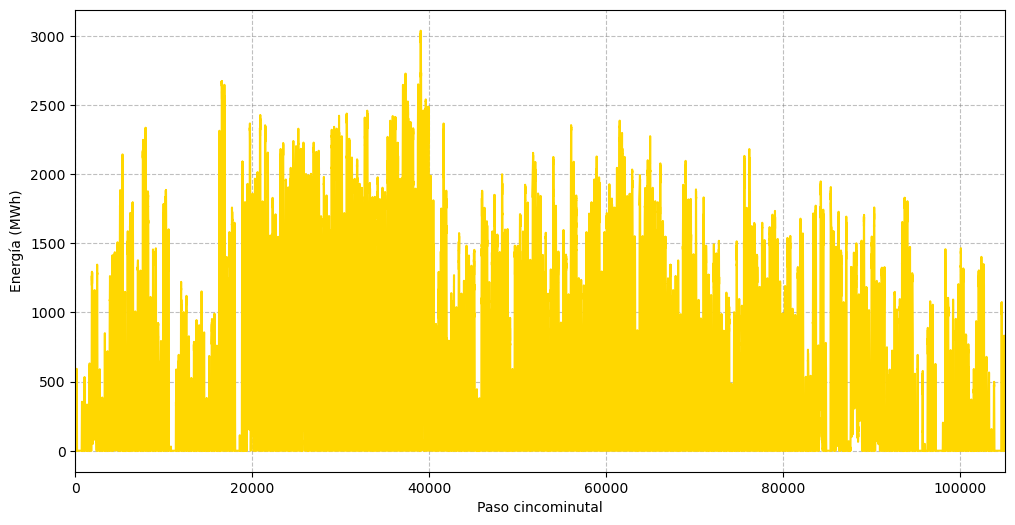

In [157]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Exceso_R_sin_almacenamiento"]/12, label="Potencia renovable perdida", color="gold")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.savefig("Exceso_R_CCG.png", dpi=300, bbox_inches='tight')

In [158]:
ER_perdida_total = esc_r_ccg["Exceso_R_sin_almacenamiento"].sum()
energia_total_ccg = esc_r_ccg["CCG_necesario"].sum()

print(f"ER perdida sin almacenamiento: {round(ER_perdida_total, 2)} (MW) -> {round((ER_perdida_total) / 12, 2)} MWh")
print(f"Energía total producida por CCG: {round(energia_total_ccg, 2)} (MW) -> {round((energia_total_ccg) / 12, 2)} MWh")

ER perdida sin almacenamiento: 568430464.06 (MW) -> 47369205.34 MWh
Energía total producida por CCG: 678251349.99 (MW) -> 56520945.83 MWh


In [159]:
# Leemos específicamente la celda P6 de la hoja correcta dónde está la potencia instalada del CCG
potencia_ccg = pd.read_excel(
    archivo,
    sheet_name="Potencia instalada", 
    usecols="P",                     
    skiprows=5,                      
    nrows=1,                         
    header=None).iloc[0, 0]                         

print("Potencia CCG según PNIEC (MWh):", potencia_ccg)

horas_equivalentes_R = energia_total_ccg/ 12 / potencia_ccg 
print(f"Horas equivalentes de funcionamiento CCG: {round(horas_equivalentes_R, 2)}")

Potencia CCG según PNIEC (MWh): 24498
Horas equivalentes de funcionamiento CCG: 2307.17


Si se quiere evitar el curtailment de las energías renovables, obtener el almacenamiento necesario y obtener las horas equivalentes de funcionamiento de las centrales de CCG

In [160]:
def almacenamiento_minimo_sin_curtailment_con_reserva(df, col_gen="Renovable", col_cons="Consumo", frac_min=0.1):
    out = df.copy()
    delta = out[col_gen] - out[col_cons]
    n = len(delta)

    flujo = np.zeros(n)
    almacen_util = np.zeros(n)
    ccg = np.zeros(n)

    s_util = 0
    s_util_max = 0

    for i in range(n):
        d = delta.iloc[i]

        if d > 0:
            # cargar almacenamiento (guardamos todo el excedente)
            s_util += d
            flujo[i] = d
        else:
            # descargar almacenamiento (solo hasta que s_util llegue a 0)
            descarga = min(-d, s_util)
            s_util -= descarga
            flujo[i] = -descarga

            # lo que falte lo cubre el CCG
            ccg[i] = (-d) - descarga

        almacen_util[i] = s_util
        
        # Guardamos el pico máximo de capacidad útil que hemos necesitado
        s_util_max = max(s_util_max, s_util)

    # === CÁLCULOS FINALES CON LA RESERVA ===
    # Si la capacidad útil es el 90% (1 - frac_min), el Smax total es:
    Smax = s_util_max / (1 - frac_min)
    
    # El mínimo técnico es ese % del Smax
    Smin = frac_min * Smax

    out["Delta"] = delta
    out["Flujo_almacenamiento"] = flujo
    out["Almacenamiento_util"] = almacen_util
    # La energía total almacenada es la útil más el colchón del mínimo técnico
    out["Almacenamiento_total"] = almacen_util + Smin
    out["CCG"] = ccg

    return out, Smax, Smin

In [161]:
esc_r_ccg_opt, Smax_ccg, Smin_ccg = almacenamiento_minimo_sin_curtailment_con_reserva(
    esc_r_ccg,
    col_gen="Renovable",
    col_cons="Consumo",
    frac_min=0.1
)

print(f"Capacidad total necesaria (Smax): {round(Smax_ccg / 12, 2)} MWh")
print(f"Mínimo técnico (Smin): {round(Smin_ccg / 12, 2)} MWh")
print(f"Capacidad útil: {round((Smax_ccg - Smin_ccg) / 12, 2)} MWh")

Capacidad total necesaria (Smax): 9486863.03 MWh
Mínimo técnico (Smin): 948686.3 MWh
Capacidad útil: 8538176.73 MWh


In [162]:
exceso = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0)

excedente_total_MWh = exceso.sum() / 12
almacenamiento_max_MWh = esc_r_ccg_opt["Almacenamiento_total"].max() / 12

print(f"Excedente renovable total (MWh): {round(excedente_total_MWh, 2)}")
print(f"Almacenamiento máximo utilizado (MWh): {round(almacenamiento_max_MWh, 2)}")

Excedente renovable total (MWh): 47369205.34
Almacenamiento máximo utilizado (MWh): 9486863.03


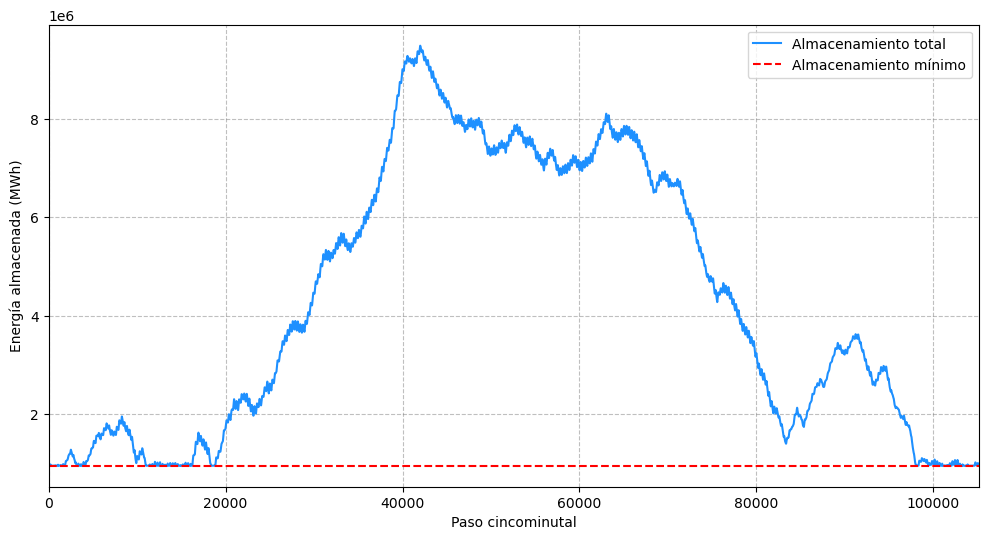

In [163]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_opt["Almacenamiento_total"]/12, label="Almacenamiento total", color="dodgerblue")
plt.axhline(Smin_ccg/12, linestyle="--", label="Almacenamiento mínimo", color="red")
plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("Alm_curt_R_CCG.png", dpi=300, bbox_inches='tight')

In [164]:
energia_ccg_MWh = esc_r_ccg_opt["CCG"].sum()/12

print(f"Energía anual CCG (MWh): {energia_ccg_MWh:.2f}")

horas_equivalentes_CCG = energia_ccg_MWh / potencia_ccg 
print(f"Horas equivalentes de funcionamiento CCG: {horas_equivalentes_CCG:.2f}")

Energía anual CCG (MWh): 9151740.49
Horas equivalentes de funcionamiento CCG: 373.57


### Máximo almacenamiento de 50 GWh

A continuación analizamos el caso de limitar el almacenamiento a 50 GWh dado que  la cantidad de almacenamiento encesarion en los casos anteriores no es realista. Se analizará si se satisface el 100% de la demanda, cuánta ER se pierde y se obtendrán las horas equivalentes de funcionamiento de las centrales de CCG.

In [165]:
def simulacion_limite_bateria_y_ccg(df, potencia_ccg, col_gen="Renovable", col_cons="Consumo", Smax_MWh=50000, frac_min=0.1):
    
    out = df.copy()
    delta = out[col_gen] - out[col_cons]
    n = len(delta)

    Smax = Smax_MWh * 12
    Smin = frac_min * Smax

    almacen_total = np.zeros(n)
    almacen_util = np.zeros(n)
    ccg = np.zeros(n)
    vertido = np.zeros(n)
    demanda_fallada = np.zeros(n)

    s = Smin 

    for i in range(n):
        d = delta.iloc[i]

        if d > 0:
            carga = min(d, Smax - s)
            s += carga
            vertido[i] = d - carga
        else:
            descarga = min(-d, s - Smin)
            s -= descarga
            
            # Lo que no pueda cubrir la batería, se lo pedimos al CCG
            deficit_restante = (-d) - descarga
            
            # EL CAMBIO CLAVE: El CCG genera como máximo su potencia instalada
            generacion_ccg = min(deficit_restante, potencia_ccg)
            ccg[i] = generacion_ccg
            
            # Si el déficit era mayor que lo que puede dar el CCG, hay apagón
            demanda_fallada[i] = deficit_restante - generacion_ccg

        almacen_total[i] = s
        almacen_util[i] = s - Smin

    out["Almacenamiento_total"] = almacen_total
    out["Almacenamiento_util"] = almacen_util
    out["CCG"] = ccg
    out["Vertido_ER"] = vertido
    out["Demanda_No_Cubierta"] = demanda_fallada

    return out

In [166]:
esc_r_ccg_50 = simulacion_limite_bateria_y_ccg(
    esc_r_ccg,
    potencia_ccg,
    col_gen="Renovable",
    col_cons="Consumo",
    Smax_MWh=50000,
    frac_min=0.1)

Smax_MWh=50000

demanda_no_cubierta = esc_r_ccg_50["Demanda_No_Cubierta"].sum() / 12
ER_perdida = esc_r_ccg_50["Vertido_ER"].sum() / 12
energia_ccg_50_MWh = esc_r_ccg_50["CCG"].sum() / 12
horas_equivalentes_50 = energia_ccg_50_MWh / potencia_ccg

print(f"Demanda no cubierta (MWh): {round(demanda_no_cubierta, 2)}")
print(f"Energía renovable perdida (MWh): {round(ER_perdida, 2)}")
print(f"Energía total generada por CCG (MWh): {round(energia_ccg_50_MWh, 2)}")
print(f"Horas equivalentes CCG: {round(horas_equivalentes_50, 2)} horas")

Demanda no cubierta (MWh): 30418.46
Energía renovable perdida (MWh): 33846843.17
Energía total generada por CCG (MWh): 42968165.2
Horas equivalentes CCG: 1753.95 horas


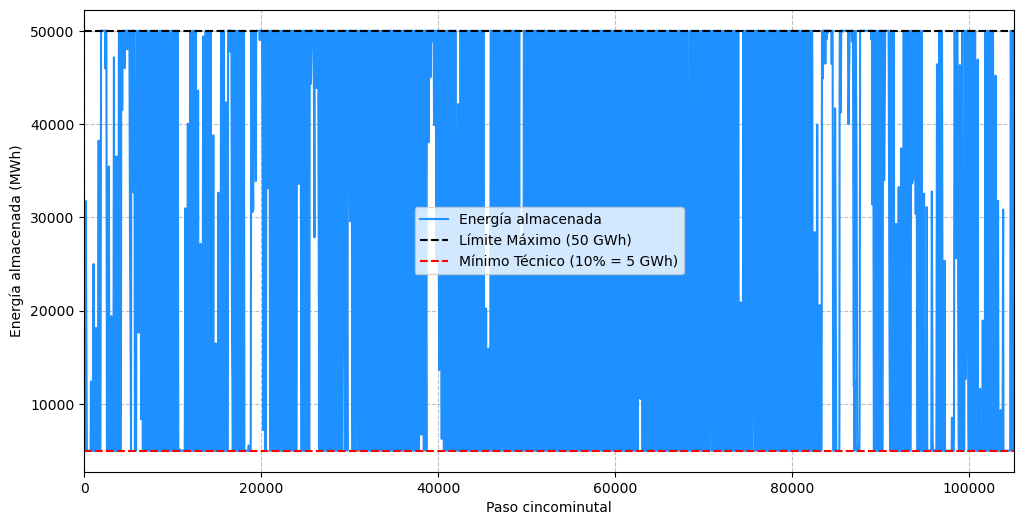

In [167]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_50["Almacenamiento_total"] / 12, label="Energía almacenada", color="dodgerblue")

Smin_MWh=0.1*Smax_MWh

plt.axhline(Smax_MWh, color="black", linestyle="--", label="Límite Máximo (50 GWh)")
plt.axhline(Smin_MWh, color="red", linestyle="--", label="Mínimo Técnico (10% = 5 GWh)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.xlim(0,105120)

plt.legend(loc="center")
plt.savefig("Alm_R_CCG_limitado.png", dpi=300, bbox_inches='tight')

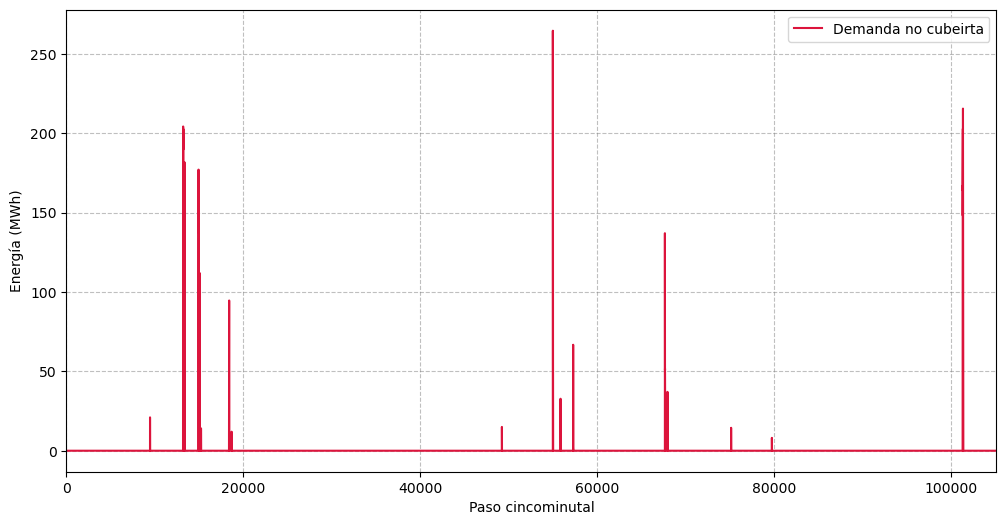

In [168]:
plt.figure(figsize=(12,6))

# Dibujamos la curva del almacenamiento total (dividida entre 12 para que sean MWh)
plt.plot(esc_r_ccg_50["Demanda_No_Cubierta"] / 12, label="Demanda no cubeirta", color="crimson")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("No_cubierta_R_CCG.png", dpi=300, bbox_inches='tight')

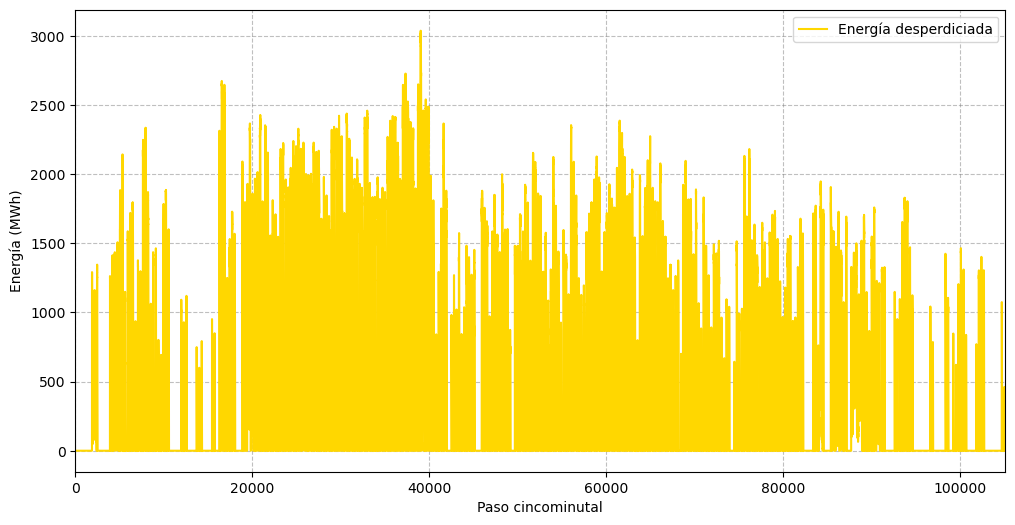

In [180]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_50["Vertido_ER"]/12, color="gold", label="Energía desperdiciada")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.legend(loc="best")
plt.xlim(0,105120)
plt.savefig("Exceso_R_CCG_limitado.png", dpi=300, bbox_inches='tight')

# R+CCG+N

A continuación, se realzia el mismo análisis del caso anterior pero teniendo en cuenta que aún quedan centrales nucleares en activo a pesar de su orden de cierre.

In [170]:
esc_r_n_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hora": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"],
    "Nuclear": df_2030r["Nuclear"]})

# Generación base sin CCG
esc_r_n_ccg["Gen_R_N"] = esc_r_n_ccg["Renovable"] + esc_r_n_ccg["Nuclear"]

esc_r_n_ccg.head()

,Fecha,Hora,Consumo,Renovable,Nuclear,Gen_R_N
0,2023-01-01,00:00:00,20671.20,15249.71,2762.30,18012.01
1,2023-01-01,00:05:00,19888.20,14274.73,2763.58,17038.31
2,2023-01-01,00:10:00,19476.40,13427.51,2764.43,16191.94
3,2023-01-01,00:15:00,19307.04,13269.38,2763.15,16032.53
4,2023-01-01,00:20:00,19092.44,13047.16,2762.30,15809.46


### Sin almacenamiento

In [171]:
esc_r_n_ccg["CCG"] = np.maximum(esc_r_n_ccg["Consumo"] - esc_r_n_ccg["Gen_R_N"], 0)

esc_r_n_ccg["Vertido_ER"] = np.maximum(esc_r_n_ccg["Gen_R_N"] - esc_r_n_ccg["Consumo"], 0)

In [172]:
ER_perdida = esc_r_n_ccg["Vertido_ER"].sum() / 12

print("ER perdida sin almacenamiento (MWh):", ER_perdida)

ER perdida sin almacenamiento (MWh): 57387980.972496726


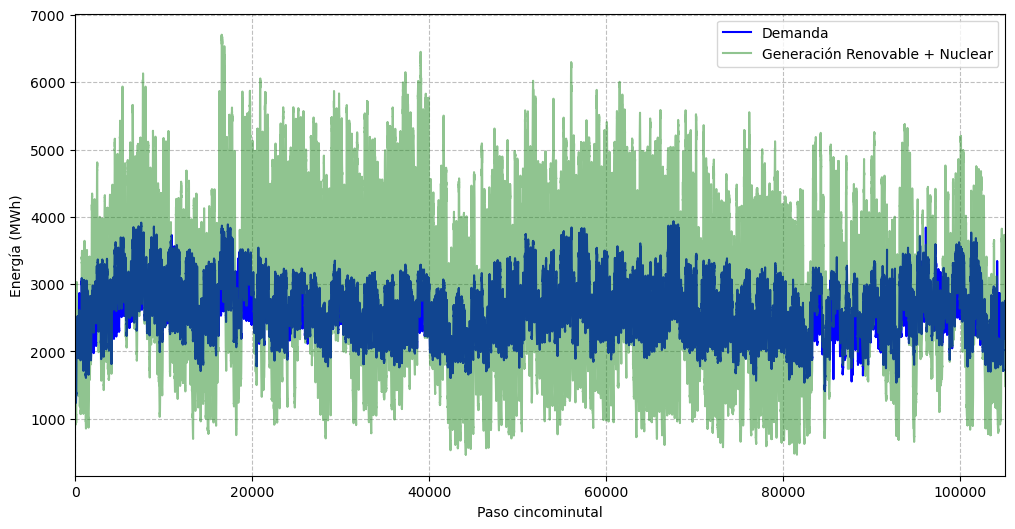

In [173]:
plt.figure(figsize=(12, 6))
plt.plot(esc_r_n_ccg["Consumo"]/12, label="Demanda", color="blue", linewidth=1.5)
plt.plot(esc_r_n_ccg["Gen_R_N"]/12, label="Generación Renovable + Nuclear", color="forestgreen", alpha=0.5)

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("Gen_R_CCG_N.png", dpi=300, bbox_inches='tight')

### Evitar Curtailment


--- RESULTADOS PARA EVITAR CURTAILMENT ---
Capacidad total necesaria de la batería (Smax): 20303236.65 MWh
Capacidad útil de la batería: 18272912.98 MWh
Horas equivalentes de funcionamiento CCG: 73.31 horas


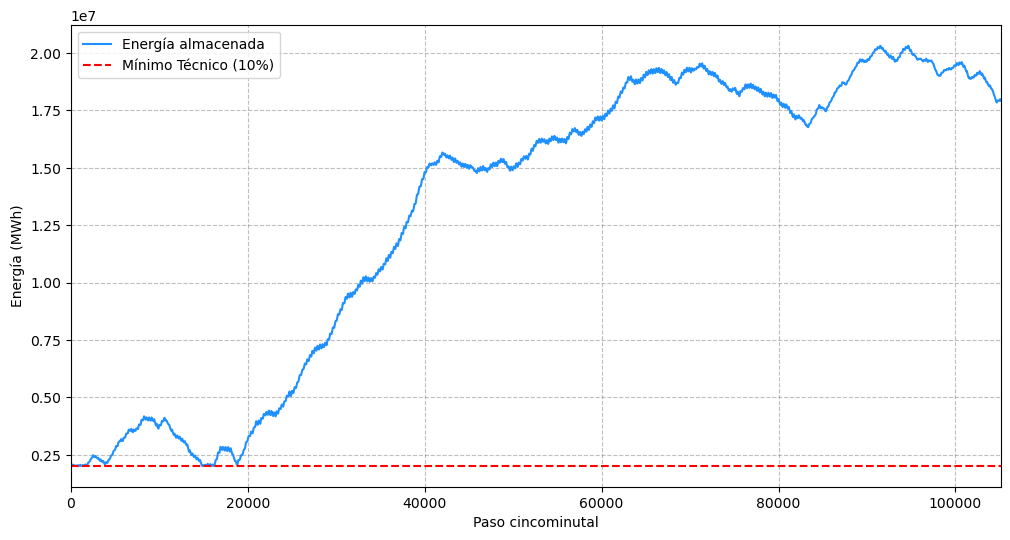

In [174]:
esc_r_n_ccg_opt, Smax_RN, Smin_RN = almacenamiento_minimo_sin_curtailment_con_reserva(
    esc_r_n_ccg,            
    col_gen="Gen_R_N",      
    col_cons="Consumo",
    frac_min=0.1)

# Convertimos a MWh
Smax_RN_MWh = Smax_RN / 12
Smin_RN_MWh = Smin_RN / 12
energia_ccg_RN_MWh = esc_r_n_ccg_opt["CCG"].sum() / 12
horas_equivalentes_RN = energia_ccg_RN_MWh / potencia_ccg

print("\n--- RESULTADOS PARA EVITAR CURTAILMENT ---")
print(f"Capacidad total necesaria de la batería (Smax): {round(Smax_RN_MWh, 2)} MWh")
print(f"Capacidad útil de la batería: {round(Smax_RN_MWh - Smin_RN_MWh, 2)} MWh")
print(f"Horas equivalentes de funcionamiento CCG: {round(horas_equivalentes_RN, 2)} horas")

# GRÁFICA: Evolución de la batería óptima
plt.figure(figsize=(12, 6))
plt.plot(esc_r_n_ccg_opt["Almacenamiento_total"] / 12, label="Energía almacenada", color="dodgerblue")
plt.axhline(Smin_RN_MWh, color="red", linestyle="--", label="Mínimo Técnico (10%)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("Alm_R_CCG_N.png", dpi=300, bbox_inches='tight')

In [175]:
esc_r_n_ccg_50 = simulacion_limite_bateria_y_ccg(
    esc_r_n_ccg,             # Tu DataFrame que ya tiene la columna de Nuclear
    potencia_ccg,
    col_gen="Gen_R_N",       # Generación base = Renovable + Nuclear
    col_cons="Consumo",
    Smax_MWh=50000,          # Límite físico de 50 GWh
    frac_min=0.1,            # 10% de mínimo técnico para proteger la batería
)

demanda_no_cubierta_RN_50 = esc_r_n_ccg_50["Demanda_No_Cubierta"].sum() / 12
ER_perdida_RN_50 = esc_r_n_ccg_50["Vertido_ER"].sum() / 12
energia_ccg_RN_50 = esc_r_n_ccg_50["CCG"].sum() / 12
horas_ccg_RN_50 = energia_ccg_RN_50 / potencia_ccg

print("--- RESULTADOS CON LÍMITE DE 50 GWh (R + Nuclear + CCG) ---")
print(f"1. Demanda no cubierta (MWh): {round(demanda_no_cubierta_RN_50, 2)}")
print(f"2. Energía vertida/perdida (MWh): {round(ER_perdida_RN_50, 2)}")
print(f"3. Horas equivalentes CCG: {round(horas_ccg_RN_50, 2)} horas")

--- RESULTADOS CON LÍMITE DE 50 GWh (R + Nuclear + CCG) ---
1. Demanda no cubierta (MWh): 7.38
2. Energía vertida/perdida (MWh): 44444754.59
3. Horas equivalentes CCG: 1239.15 horas


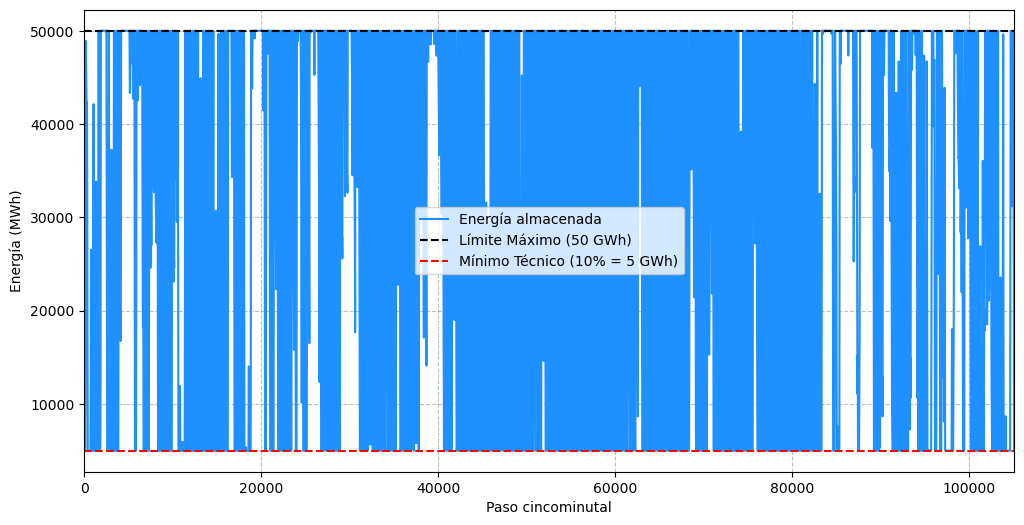

In [183]:
plt.figure(figsize=(12, 6))

plt.plot(esc_r_n_ccg_50["Almacenamiento_total"] / 12, label="Energía almacenada", color="dodgerblue")

plt.axhline(50000, color="black", linestyle="--", label="Límite Máximo (50 GWh)")
plt.axhline(5000, color="red", linestyle="--", label="Mínimo Técnico (10% = 5 GWh)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.legend(loc="center")
plt.xlim(0,105120)
plt.savefig("Alm_R_CCG_N_limitado.png", dpi=300, bbox_inches='tight')

7.375132570883579


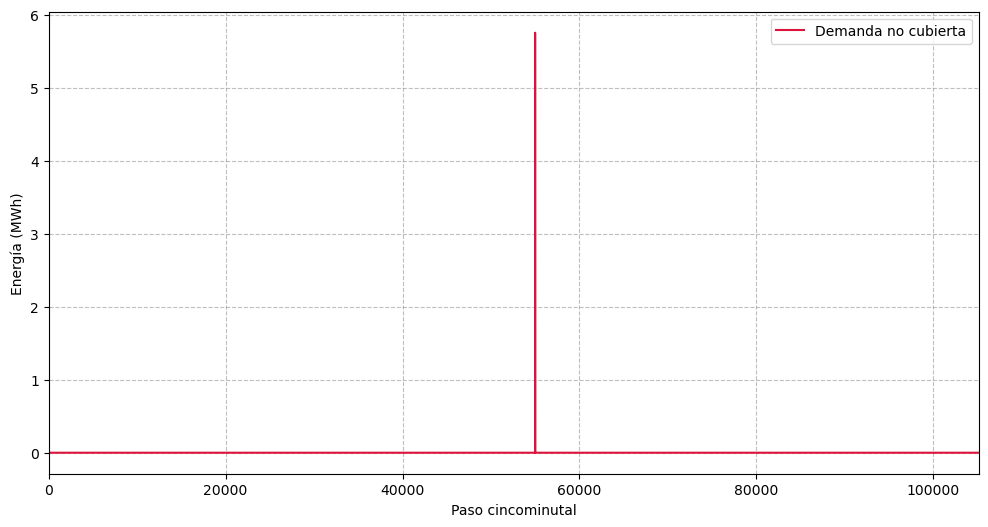

In [188]:
plt.figure(figsize=(12,6))
plt.plot(esc_r_n_ccg_50["Demanda_No_Cubierta"] / 12, label="Demanda no cubierta", color="crimson")
print(demanda_no_cubierta_RN_50)
plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("No_cubierta_R_CCG_N.png", dpi=300, bbox_inches='tight')

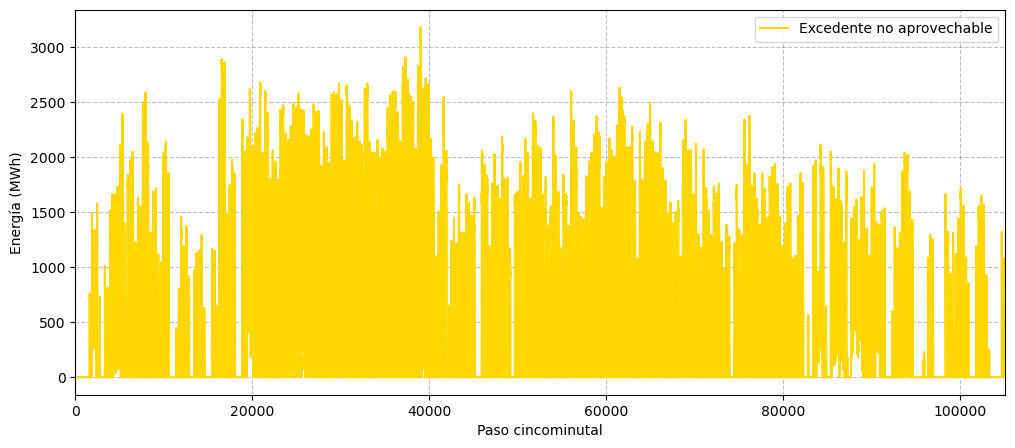

In [178]:
plt.figure(figsize=(12, 5)) 

plt.plot(esc_r_n_ccg_50["Vertido_ER"]/12, color="gold", label="Excedente no aprovechable")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía (MWh)")
plt.xlim(0,105120)
plt.legend(loc="best")
plt.savefig("Exceso_R_CCG_N_limitado.png", dpi=300, bbox_inches='tight')